# 小データでの機械学習——研究現場で使える現実的な戦略

このnotebookはZenn記事「小データでの機械学習——研究現場で使える現実的な戦略」のコード実装版です。  
記事で取り上げた7つのコードブロックを実際に動かしながら確認できます。

## 目次
1. [共通セットアップ・デモデータ生成](#1)
2. [モデル比較（LOOCV）](#2)
3. [正則化パラメータのCV選択](#3)
4. [Nested CV + GroupKFold（データリーク防止）](#4)
5. [学習曲線による診断](#5)
6. [GPR による予測と不確実性の定量化](#6)
7. [簡易ベイズ最適化（EI 獲得関数）](#7)
8. [PLS vs PCA の次元削減比較](#8)


## 1. 共通セットアップ・デモデータ生成 <a id="1"></a>

合金の実験データを模した**デモデータセット**を生成します。

- **サンプル数**：n = 80（小データの典型的な規模）
- **特徴量**：元素組成3種（Fe, Ni, Cr の wt%）、合成温度、焼成時間、冷却速度
- **目標変数**：引張強度（MPa）＝ドメイン知識に基づく非線形式 + ノイズ
- **グループ構造**：4つの実験バッチ（GroupKFold のデモ用）


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 日本語フォント設定（macOS）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False

np.random.seed(42)
n = 80

# --- デモデータ生成（合金実験データを模したもの）---
# 組成（wt%）：合計 ≤ 100%になるよう設定
Fe = np.random.uniform(50, 75, n)
Ni = np.random.uniform(10, 25, n)
Cr = 100 - Fe - Ni - np.random.uniform(5, 15, n)
Cr = np.clip(Cr, 2, 20)

temp   = np.random.uniform(900, 1200, n)   # 焼成温度（℃）
time   = np.random.uniform(1, 8, n)        # 焼成時間（h）
cool_r = np.random.uniform(1, 50, n)       # 冷却速度（℃/min）

# 目標変数：引張強度（MPa）＝非線形な物理式 + ノイズ
y = (
    200
    + 3.5 * Ni
    - 0.8 * Cr
    + 0.12 * temp
    + 10  * np.log1p(time)
    - 0.5 * cool_r
    + 0.002 * temp * Ni        # 交互作用項
    + np.random.normal(0, 15, n)  # 測定ノイズ
)

# グループ構造（実験バッチ）：GroupKFold のデモ用
batch_id = np.repeat([0, 1, 2, 3], [20, 20, 20, 20])

df = pd.DataFrame({
    "Fe_wt":   Fe,
    "Ni_wt":   Ni,
    "Cr_wt":   Cr,
    "temp":    temp,
    "time":    time,
    "cool_r":  cool_r,
    "batch_id": batch_id,
    "target":  y
})

print(f"データ形状: {df.shape}")
print(f"\n統計サマリー:")
print(df.describe().round(2))


データ形状: (80, 8)

統計サマリー:
       Fe_wt  Ni_wt  Cr_wt     temp   time  cool_r  batch_id  target
count  80.00  80.00  80.00    80.00  80.00   80.00     80.00   80.00
mean   61.65  17.33  11.12  1060.08   4.48   25.85      1.50  419.81
std     7.64   4.34   7.11    89.79   2.05   15.97      1.13   37.01
min    50.14  10.10   2.00   904.64   1.10    1.53      0.00  342.03
25%    54.61  13.71   4.15   988.27   2.90    7.71      0.75  395.25
50%    60.90  17.37  11.77  1062.49   4.67   26.19      1.50  418.94
75%    68.55  21.35  19.12  1140.32   6.19   40.05      2.25  451.00
max    74.67  24.78  20.00  1197.02   7.93   49.66      3.00  505.61


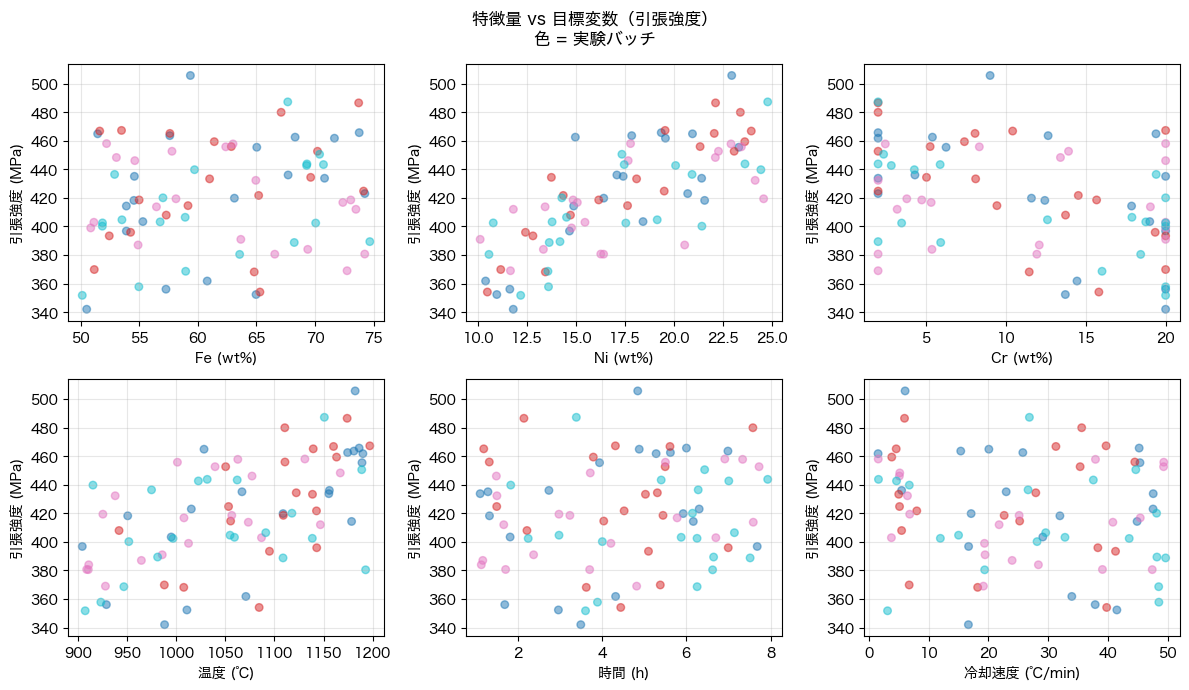


ターゲット変数の範囲: 342.0 ~ 505.6 MPa


In [7]:
# データの可視化
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
feature_cols = ["Fe_wt", "Ni_wt", "Cr_wt", "temp", "time", "cool_r"]
labels = ["Fe (wt%)", "Ni (wt%)", "Cr (wt%)", "温度 (℃)", "時間 (h)", "冷却速度 (℃/min)"]

for ax, col, label in zip(axes.flat, feature_cols, labels):
    ax.scatter(df[col], df["target"], alpha=0.5, s=30, c=df["batch_id"], cmap="tab10")
    ax.set_xlabel(label)
    ax.set_ylabel("引張強度 (MPa)")
    ax.grid(True, alpha=0.3)

plt.suptitle("特徴量 vs 目標変数（引張強度）\n色 = 実験バッチ", fontsize=12)
plt.tight_layout()
plt.show()
print(f"\nターゲット変数の範囲: {y.min():.1f} ~ {y.max():.1f} MPa")


## 2. モデル比較（LOOCV） <a id="2"></a>

n = 80 のデータに対して、5種類のモデルを**Leave-One-Out CV**で評価します。

**ポイント：**
- Random Forestは `max_depth=3` で過学習を抑制
- GPRはカーネル関数で非線形性を表現しながら不確実性も出力
- まずはRidgeのベースライン R² を確認してから他モデルと比較する


In [8]:
# df はあらかじめ実験データが格納されている DataFrame とします
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.pipeline import Pipeline

# バッチIDとターゲットを除いた特徴量
X = df.drop(columns=["target", "batch_id"]).values
y = df["target"].values

# --- モデル定義 ---
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
models = {
    "Ridge":        Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=1.0))]),
    "Lasso":        Pipeline([("sc", StandardScaler()), ("m", Lasso(alpha=0.01, max_iter=5000))]),
    "SVR":          Pipeline([("sc", StandardScaler()), ("m", SVR(kernel="rbf", C=10, epsilon=0.1))]),
    "RF(depth=3)":  Pipeline([("sc", StandardScaler()), ("m", RandomForestRegressor(n_estimators=200, max_depth=3, random_state=42))]),
    "GPR":          Pipeline([("sc", StandardScaler()), ("m", GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42))]),
}

from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_predict

# --- LOOCV で評価 ---
loo = LeaveOneOut()
rows = []
model_names, r2_scores, mae_means, mae_stds = [], [], [], []

print("モデル評価中（LOOCVは少し時間がかかります）...")
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=loo)
    r2 = r2_score(y, y_pred)
    mae_per_sample = np.abs(y - y_pred)

    model_names.append(name)
    r2_scores.append(r2)
    mae_means.append(mae_per_sample.mean())
    mae_stds.append(mae_per_sample.std())

    rows.append({
        "Model": name,
        "LOOCV R2": f"{r2:.3f}",
        "LOOCV MAE (MPa)": f"{mae_per_sample.mean():.1f} ± {mae_per_sample.std():.1f}",
    })
    print(f"  {name} 完了")

result_df = pd.DataFrame(rows)
print("\n--- モデル比較結果 ---")
print(result_df.to_string(index=False))


モデル評価中（LOOCVは少し時間がかかります）...
  Ridge 完了
  Lasso 完了
  SVR 完了
  RF(depth=3) 完了
  GPR 完了

--- モデル比較結果 ---
      Model LOOCV R2 LOOCV MAE (MPa)
      Ridge    0.804      13.4 ± 9.2
      Lasso    0.803      13.4 ± 9.3
        SVR    0.657     17.6 ± 12.5
RF(depth=3)    0.731     15.9 ± 10.6
        GPR    0.802      13.6 ± 9.1


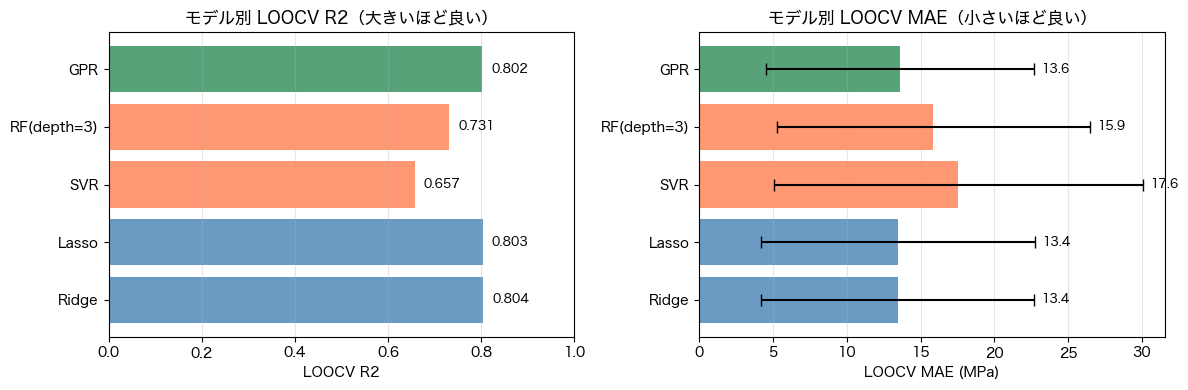

In [9]:
# LOOCV R2 / MAE の棒グラフ比較（セル5の結果を可視化）
colors = ["steelblue", "steelblue", "coral", "coral", "seagreen"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：R2（大きいほど良い）
ax = axes[0]
ax.barh(model_names, r2_scores, color=colors, alpha=0.8)
ax.set_xlabel("LOOCV R2")
ax.set_title("モデル別 LOOCV R2（大きいほど良い）")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3, axis="x")
for i, score in enumerate(r2_scores):
    ax.text(min(score + 0.02, 0.95), i, f"{score:.3f}", va="center", fontsize=9)

# 右：MAE（小さいほど良い）
ax = axes[1]
ax.barh(model_names, mae_means, xerr=mae_stds, color=colors, capsize=4, alpha=0.8)
ax.set_xlabel("LOOCV MAE (MPa)")
ax.set_title("モデル別 LOOCV MAE（小さいほど良い）")
ax.grid(True, alpha=0.3, axis="x")
for i, (mean, std) in enumerate(zip(mae_means, mae_stds)):
    ax.text(mean + std + 0.5, i, f"{mean:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 3. 正則化パラメータのCV選択 <a id="3"></a>

Ridge/Lasso/ElasticNet の正則化強度 α を、クロスバリデーションで自動選択します。  
`RidgeCV` などの `*CV` クラスを使うと、内部でグリッドサーチを行い最適な α を返します。

`Ridge` の係数を確認することで、「どの特徴量がターゲットへの影響が大きいか」を  
物理的知識と照合できます。


--- 最適な正則化パラメータ ---
  Ridge: best α = 8.28643
  Lasso: best α = 0.65513
  ElasticNet: best α = 0.49417


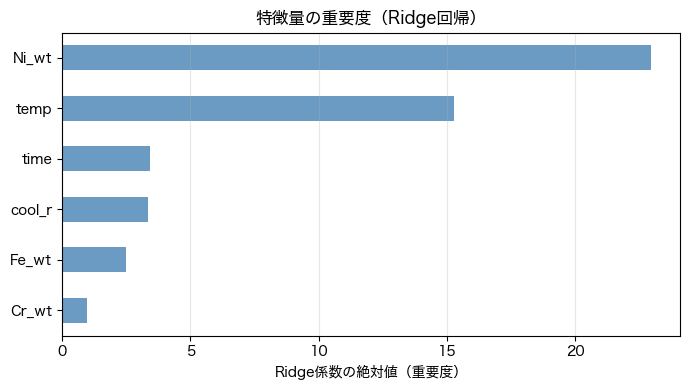

In [10]:
# df はあらかじめ実験データが格納されている DataFrame とします
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

X = df.drop(columns=["target", "batch_id"]).values
y = df["target"].values
feature_names = df.drop(columns=["target", "batch_id"]).columns.tolist()

alphas = np.logspace(-3, 3, 50)

ridge_cv   = Pipeline([("sc", StandardScaler()), ("m", RidgeCV(alphas=alphas, cv=5, scoring="r2"))])
lasso_cv   = Pipeline([("sc", StandardScaler()), ("m", LassoCV(alphas=alphas, cv=5, max_iter=10000))])
elastic_cv = Pipeline([("sc", StandardScaler()), ("m", ElasticNetCV(
    alphas=alphas, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0], cv=5, max_iter=10000))])

print("--- 最適な正則化パラメータ ---")
for name, pipe in [("Ridge", ridge_cv), ("Lasso", lasso_cv), ("ElasticNet", elastic_cv)]:
    pipe.fit(X, y)
    model = pipe.named_steps["m"]
    best_alpha = getattr(model, "alpha_", "N/A")
    print(f"  {name}: best α = {best_alpha:.5f}")

# Ridge の係数（物理的解釈）
coef = ridge_cv.named_steps["m"].coef_
importance = pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Ridge係数の絶対値（重要度）")
ax.set_title("特徴量の重要度（Ridge回帰）")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


## 4. Nested CV + GroupKFold（データリーク防止） <a id="4"></a>

**小データ特有のデータリーク：グループ構造の無視**

同一実験バッチや同一組成系のサンプル群は強い類似性を持ちます。  
これをランダム分割で train/test に混在させると、モデルは「記憶するだけ」で高精度を出します。

**解決策：**
- 外側CV（汎化性能評価）は `GroupKFold`（バッチ単位で分割）
- 内側CV（ハイパーパラメータ選択）は通常の `KFold`
- これを **Nested CV** と呼ぶ


In [11]:
# df はあらかじめ実験データが格納されている DataFrame とします
from sklearn.model_selection import GroupKFold, KFold, GridSearchCV

X = df.drop(columns=["target", "batch_id"]).values
y = df["target"].values
groups = df["batch_id"].values   # バッチID（グループラベル）

# 比較1: 通常のK-Fold（グループ無視）
pipe = Pipeline([("sc", StandardScaler()), ("m", Ridge())])
param_grid = {"m__alpha": np.logspace(-3, 3, 20)}

kfold_scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for tr, te in kf.split(X):
    gs = GridSearchCV(pipe, param_grid, cv=KFold(3, shuffle=True, random_state=0), scoring="r2")
    gs.fit(X[tr], y[tr])
    kfold_scores.append(gs.score(X[te], y[te]))

# 比較2: GroupKFold（バッチ単位で分割）
group_scores = []
gkf = GroupKFold(n_splits=4)
for tr, te in gkf.split(X, y, groups):
    gs = GridSearchCV(pipe, param_grid, cv=KFold(3, shuffle=True, random_state=0), scoring="r2")
    gs.fit(X[tr], y[tr])
    group_scores.append(gs.score(X[te], y[te]))

print("--- データリークの影響 ---")
print(f"  通常K-Fold   Nested CV R²: {np.mean(kfold_scores):.3f} ± {np.std(kfold_scores):.3f}")
print(f"  GroupKFold   Nested CV R²: {np.mean(group_scores):.3f} ± {np.std(group_scores):.3f}")
print()
print("※ GroupKFold の方がより保守的（現実的）な推定値になる場合が多い")


--- データリークの影響 ---
  通常K-Fold   Nested CV R²: 0.761 ± 0.104
  GroupKFold   Nested CV R²: 0.760 ± 0.092

※ GroupKFold の方がより保守的（現実的）な推定値になる場合が多い


## 5. 学習曲線による診断 <a id="5"></a>

学習曲線（Learning Curve）でモデルの状態を診断します。

- **過学習**：Train R² が高く、CV R² が低いまま乖離 → 正則化を強化 or モデルを単純化
- **アンダーフィット**：両者がともに低い → 特徴量が不足 or モデルが単純すぎ
- **収束**：両者が接近している → データを増やしても精度頭打ち、特徴量の質が問題


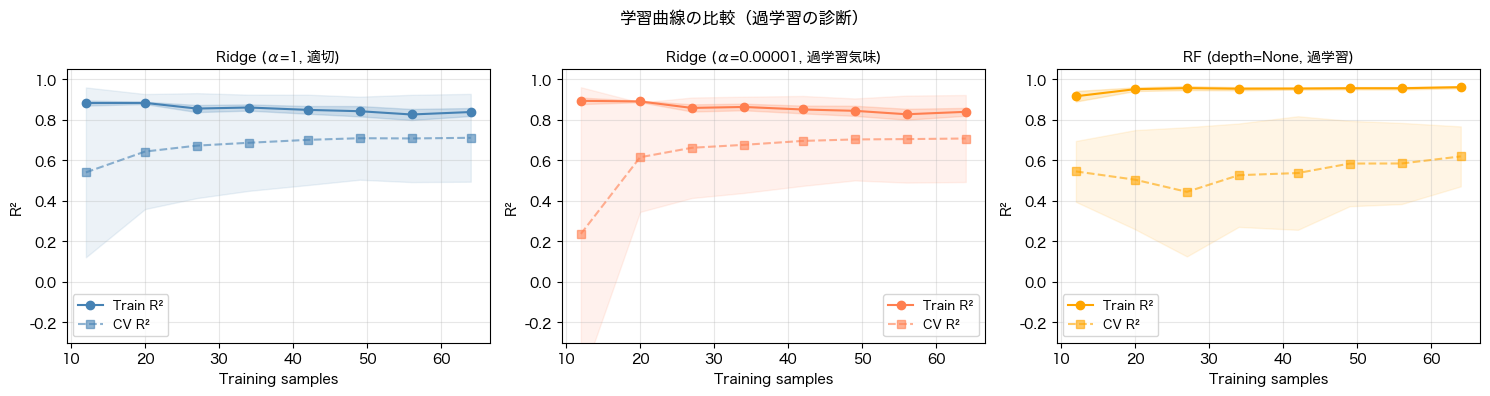

In [12]:
# df はあらかじめ実験データが格納されている DataFrame とします
from sklearn.model_selection import learning_curve

X = df.drop(columns=["target", "batch_id"]).values
y = df["target"].values

# 3モデルを比較
configs = [
    ("Ridge (α=1, 適切)", Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=1.0))]), "steelblue"),
    ("Ridge (α=0.00001, 過学習気味)", Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=1e-5))]), "coral"),
    ("RF (depth=None, 過学習)", Pipeline([("sc", StandardScaler()), ("m", RandomForestRegressor(n_estimators=100, random_state=42))]), "orange"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, pipe, color) in zip(axes, configs):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y,
        train_sizes=np.linspace(0.2, 1.0, 8),
        cv=5, scoring="r2", n_jobs=-1,
        shuffle=True, random_state=42   # 訓練サイズごとにランダムサンプリング（先頭から取る偏りを防ぐ）
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color=color, label="Train R²")
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.2, color=color)
    ax.plot(train_sizes, val_scores.mean(axis=1), "s--", color=color, alpha=0.6, label="CV R²")
    ax.fill_between(train_sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.1, color=color)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("R²")
    ax.set_ylim(-0.3, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("学習曲線の比較（過学習の診断）", fontsize=12)
plt.tight_layout()
plt.show()


## 6. GPR による予測と不確実性の定量化 <a id="6"></a>

ガウス過程回帰（GPR）は予測値 μ と不確実性 σ を同時に出力します。

**重要な解釈：**
- σ が大きい = モデルがその領域を「知らない」（学習データが少ない、または遠い）
- 予測値が高くても σ が大きい → 外挿している可能性があり、実験で確認が必要
- σ が小さく予測値が高い → 自信のある良い候補


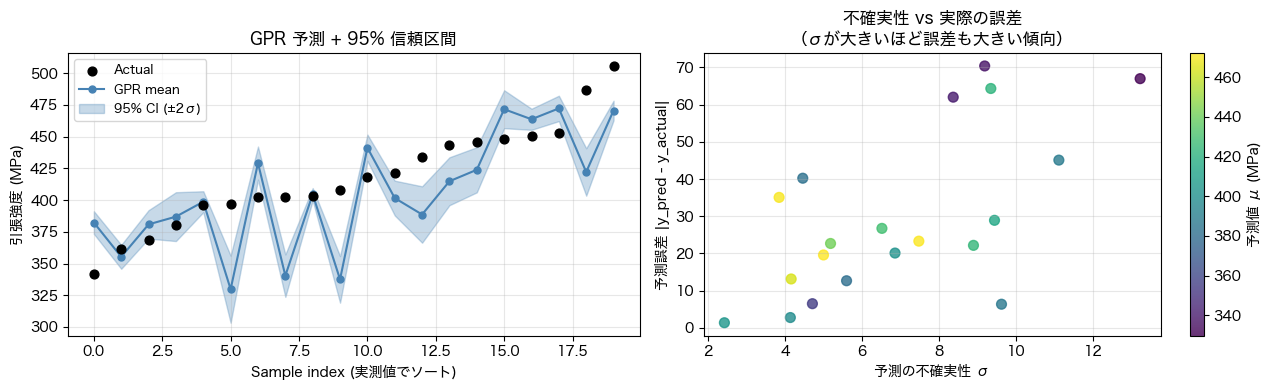


--- 不確実性の高いサンプル Top 5 ---
  y_actual  y_pred  σ (std)  error
396.774016   329.8    13.21   67.0
433.704040   388.6    11.11   45.1
380.561058   386.9     9.62    6.4
443.720969   414.8     9.44   28.9
486.452942   422.1     9.34   64.3


In [13]:
# df はあらかじめ実験データが格納されている DataFrame とします
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target", "batch_id"]).values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_train)
X_te_sc = sc.transform(X_test)

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(0.1, (1e-5, 1.0))
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr.fit(X_tr_sc, y_train)

y_pred, y_std = gpr.predict(X_te_sc, return_std=True)

# プロット：実測 vs 予測（誤差棒付き）
sorted_idx = np.argsort(y_test)
x_plot = np.arange(len(y_test))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：実測 vs 予測（信頼区間付き）
ax = axes[0]
ax.scatter(x_plot, y_test[sorted_idx], color="black", zorder=5, label="Actual", s=40)
ax.plot(x_plot, y_pred[sorted_idx], "o-", color="steelblue", label="GPR mean", markersize=5)
ax.fill_between(x_plot,
                y_pred[sorted_idx] - 2 * y_std[sorted_idx],
                y_pred[sorted_idx] + 2 * y_std[sorted_idx],
                alpha=0.3, color="steelblue", label="95% CI (±2σ)")
ax.set_xlabel("Sample index (実測値でソート)")
ax.set_ylabel("引張強度 (MPa)")
ax.set_title("GPR 予測 + 95% 信頼区間")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 右：誤差 vs 不確実性の関係
ax = axes[1]
error = np.abs(y_pred - y_test)
sc_plot = ax.scatter(y_std, error, c=y_pred, cmap="viridis", s=50, alpha=0.8)
plt.colorbar(sc_plot, ax=ax, label="予測値 μ (MPa)")
ax.set_xlabel("予測の不確実性 σ")
ax.set_ylabel("予測誤差 |y_pred - y_actual|")
ax.set_title("不確実性 vs 実際の誤差\n（σが大きいほど誤差も大きい傾向）")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- 不確実性の高いサンプル Top 5 ---")
unc_df = pd.DataFrame({
    "y_actual": y_test, "y_pred": y_pred.round(1),
    "σ (std)": y_std.round(2), "error": error.round(1)
}).sort_values("σ (std)", ascending=False)
print(unc_df.head().to_string(index=False))


## 7. 簡易ベイズ最適化（EI 獲得関数 + GPR） <a id="7"></a>

GPR の μ と σ を使って「次の実験候補」を提案するベイズ最適化（BO）を実装します。

**Expected Improvement（EI）** の直感：
- μ が高ければ Exploitation（活用）：既知の良い領域を深掘り
- σ が高ければ Exploration（探索）：未知の領域を調べてモデルを改善
- EI はこの両者を数式でバランス

実際の材料探索では、`X_candidates` に「実験可能な組成・条件の全候補リスト」を入れると  
次にやるべき実験の優先順位が得られます。


In [14]:
# df はあらかじめ実験データが格納されている DataFrame とします
from scipy.stats import norm

def expected_improvement(X_candidates, gpr, y_best, xi=0.01):
    """EI 獲得関数：候補点ごとの Expected Improvement を計算"""
    mu, sigma = gpr.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    Z = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei, mu, sigma

# 既存データで GPR を訓練
X_known = df.drop(columns=["target", "batch_id"]).values
y_known = df["target"].values
feature_cols = df.drop(columns=["target", "batch_id"]).columns.tolist()

sc = StandardScaler()
X_sc = sc.fit_transform(X_known)

kernel = ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(0.1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
gpr.fit(X_sc, y_known)

# 候補セット生成（新しい実験候補 200 件をランダムサンプリング）
np.random.seed(99)
n_cand = 200
Fe_c   = np.random.uniform(50, 75, n_cand)
Ni_c   = np.random.uniform(10, 25, n_cand)
Cr_c   = np.clip(100 - Fe_c - Ni_c - np.random.uniform(5, 15, n_cand), 2, 20)
temp_c = np.random.uniform(900, 1200, n_cand)
time_c = np.random.uniform(1, 8, n_cand)
cool_c = np.random.uniform(1, 50, n_cand)
X_candidates = np.column_stack([Fe_c, Ni_c, Cr_c, temp_c, time_c, cool_c])
X_cand_sc = sc.transform(X_candidates)

# EI を計算
y_best = y_known.max()
ei_scores, mu_scores, sigma_scores = expected_improvement(X_cand_sc, gpr, y_best)

# 上位 5 件を提案
top5_idx = np.argsort(ei_scores)[::-1][:5]
print(f"現在の最良値: {y_best:.1f} MPa")
print("\n--- 次の実験候補（EI 順） ---")
rec_rows = []
for rank, idx in enumerate(top5_idx, 1):
    row = {f: round(X_candidates[idx, i], 1) for i, f in enumerate(feature_cols)}
    row.update({"EI": round(ei_scores[idx], 4), "予測μ": round(mu_scores[idx], 1), "不確実性σ": round(sigma_scores[idx], 1)})
    rec_rows.append(row)
print(pd.DataFrame(rec_rows).to_string(index=False))


現在の最良値: 505.6 MPa

--- 次の実験候補（EI 順） ---
 Fe_wt  Ni_wt  Cr_wt   temp  time  cool_r     EI   予測μ  不確実性σ
  60.4   24.4    5.3 1196.7   6.8     7.3 1.7031 491.1   16.5
  69.8   24.6    2.0 1159.8   6.0    13.6 1.4067 489.6   16.3
  67.6   24.3    2.0 1179.8   5.9    17.0 1.2372 488.7   16.2
  72.9   24.7    2.0 1187.1   2.1    32.6 0.9211 485.3   16.8
  70.3   23.1    2.0 1194.4   6.2    32.0 0.6294 483.3   16.2


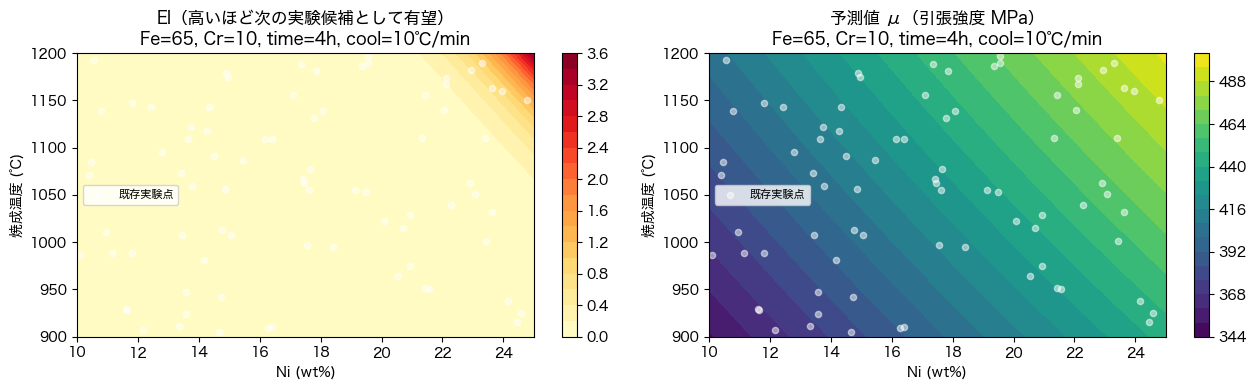

In [15]:
# EI マップの可視化（2D: Ni wt% vs 温度 で EI を表示）
Ni_grid  = np.linspace(10, 25, 50)
temp_grid = np.linspace(900, 1200, 50)
NN, TT = np.meshgrid(Ni_grid, temp_grid)

# Fe=65, Cr=10, time=4, cool=10 に固定してスキャン
Fe_fixed, Cr_fixed, time_fixed, cool_fixed = 65, 10, 4, 10
X_grid = np.column_stack([
    np.full(NN.size, Fe_fixed), NN.ravel(), np.full(NN.size, Cr_fixed),
    TT.ravel(), np.full(NN.size, time_fixed), np.full(NN.size, cool_fixed)
])
X_grid_sc = sc.transform(X_grid)
ei_grid, mu_grid, _ = expected_improvement(X_grid_sc, gpr, y_best)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, title, cmap in zip(
    axes,
    [ei_grid.reshape(NN.shape), mu_grid.reshape(NN.shape)],
    ["EI（高いほど次の実験候補として有望）", "予測値 μ（引張強度 MPa）"],
    ["YlOrRd", "viridis"]
):
    cf = ax.contourf(Ni_grid, temp_grid, data, levels=20, cmap=cmap)
    plt.colorbar(cf, ax=ax)
    ax.scatter(df["Ni_wt"], df["temp"], c="white", s=20, alpha=0.5, label="既存実験点")
    ax.set_xlabel("Ni (wt%)")
    ax.set_ylabel("焼成温度 (℃)")
    ax.set_title(title + f"\nFe={Fe_fixed}, Cr={Cr_fixed}, time={time_fixed}h, cool={cool_fixed}℃/min")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 8. PLS vs PCA の次元削減比較 <a id="8"></a>

特徴量が多い場合（または記述子を追加した場合）の次元削減比較です。

- **PCA**（教師なし）：分散が大きい方向を抽出。ターゲット変数を見ない
- **PLS**（教師あり）：ターゲット変数との共分散を最大化する方向を抽出

小データの回帰タスクでは、PLS の方が有利になることが多い。


 n_components  CV R² (PCA+Ridge)  CV R² (PLS)
            1             -0.003        0.610
            2             -0.043        0.729
            3              0.596        0.748
            4              0.714        0.741
            5              0.738        0.763
            6              0.765        0.766


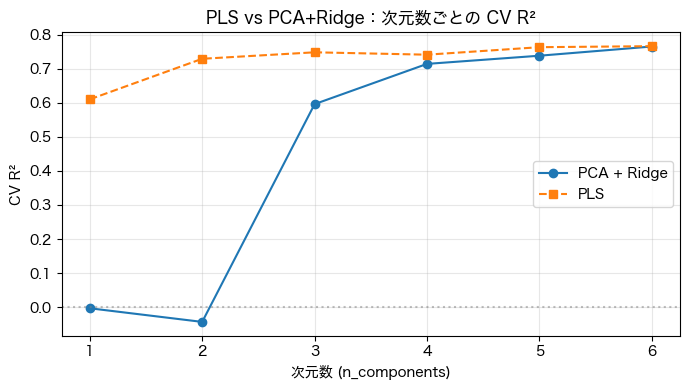

In [16]:
# df はあらかじめ実験データが格納されている DataFrame とします
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

X = df.drop(columns=["target", "batch_id"]).values
y = df["target"].values

cv = KFold(n_splits=5, shuffle=True, random_state=42)
n_components_list = [1, 2, 3, 4, 5, 6]  # 最大特徴量数=6

results = []
for n in n_components_list:
    # PCA + Ridge
    pipe_pca = Pipeline([
        ("sc",  StandardScaler()),
        ("pca", PCA(n_components=n)),
        ("m",   Ridge(alpha=1.0))
    ])
    r2_pca = cross_val_score(pipe_pca, X, y, cv=cv, scoring="r2").mean()

    # PLS
    pls = Pipeline([("sc", StandardScaler()), ("m", PLSRegression(n_components=n))])
    r2_pls = cross_val_score(pls, X, y, cv=cv, scoring="r2").mean()

    results.append({"n_components": n, "CV R² (PCA+Ridge)": round(r2_pca, 3), "CV R² (PLS)": round(r2_pls, 3)})

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

# 可視化
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(res_df["n_components"], res_df["CV R² (PCA+Ridge)"], "o-", label="PCA + Ridge")
ax.plot(res_df["n_components"], res_df["CV R² (PLS)"], "s--", label="PLS")
ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("次元数 (n_components)")
ax.set_ylabel("CV R²")
ax.set_title("PLS vs PCA+Ridge：次元数ごとの CV R²")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(n_components_list)
plt.tight_layout()
plt.show()


## チェックリスト（実データで使う前に確認）

- [ ] `max_depth` を制限した Random Forest を使ったか
- [ ] LOOCV（n<50）または Repeated K-Fold（n=50〜200）で評価したか
- [ ] `GroupKFold` でデータリーク（グループ構造の無視）を防いだか
- [ ] Nested CV でハイパーパラメータ選択と評価を分離したか
- [ ] 学習曲線で過学習 / アンダーフィットを診断したか
- [ ] GPR の σ（不確実性）を確認し、外挿領域への過信を避けているか
- [ ] EI 獲得関数で次の実験候補に Exploitation/Exploration バランスを取ったか

### 次のステップ（このnotebookで扱っていない発展的な内容）
- PHYSBO / Ax による本格的なベイズ最適化
- matminer の Magpie 特徴量を使った記述子生成
- CHGNet / M3GNet などの事前学習済みGNNモデルへの転移学習
